# Kenya Food Price Classification
## Random Forest vs XGBoost

### Objective

The objective of this analysis is to develop and compare two machine learning
classification models, **Random Forest** and **XGBoost**, for classifying food
prices in Kenya into three categories:

- Cheap
- Average
- Expensive

The models are evaluated using accuracy, precision, recall, F1-score, and
confusion matrices. Because the target classes are imbalanced, particular
attention is given to **Macro F1**, which gives each class equal importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from xgboost import XGBClassifier

# Load classification dataset
df = pd.read_csv('../../bei_smart_classification.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (16163, 29)


,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,month,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,160.000000,160.000000,160.000000,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,200.000000,200.000000,200.000000,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,200.000000,200.000000,200.000000,1.201201,Expensive
3,2024-09-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,196.666667,196.666667,196.666667,1.143326,Expensive
4,2023-12-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,12,2023,Short Rains,212.36,201.47,155.000000,155.000000,155.000000,0.888363,Cheap


## 1. Dataset Overview

Before modelling, the dataset is inspected to understand its size, variables,
data types, missing values, target distribution, and duplicate records.

In [2]:
# Dataset dimensions
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and missing values
print("\nDataset information:")
df.info()

Shape: (16163, 29)

Columns:
['date', 'region', 'county', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_month', 'rainfall_mm', 'price_per_kg', 'month', 'year', 'season', 'petrol_price_kes', 'diesel_price_kes', 'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg', 'price_vs_regional_avg', 'price_label']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 16163 entries, 0 to 16162
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   16163 non-null  str    
 1   region                 16163 non-null  str    
 2   county                 16163 non-null  str    
 3   market                 16163 non-null  str    
 4   market_id              16163 non-null  int64  
 5   latitude               16163 non-null  float64
 6   longitude              16163 non-null 

In [3]:
# Target distribution
print("Target distribution:")
print(df['price_label'].value_counts())

print("\nPercentage distribution:")
print(
    df['price_label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTarget classes:")
print(df['price_label'].unique())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Target distribution:
price_label
Average      10804
Cheap         2831
Expensive     2528
Name: count, dtype: int64

Percentage distribution:
price_label
Average      66.84
Cheap        17.52
Expensive    15.64
Name: proportion, dtype: float64

Target classes:
<ArrowStringArray>
['Average', 'Expensive', 'Cheap']
Length: 3, dtype: str

Duplicate rows: 0


In [4]:
# Profile all variables
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Unique Values': df.nunique()
})

column_info

,Column,Data Type,Unique Values
date,date,str,120
region,region,str,5
county,county,str,19
market,market,str,205
market_id,market_id,int64,205
latitude,latitude,float64,165
longitude,longitude,float64,172
category,category,str,7
commodity,commodity,str,31
commodity_id,commodity_id,int64,31


## 2. Leakage Check and Feature Selection

The target variable, `price_label`, represents food-price categories. Variables
that directly contain the current price or are derived from it can give the
model information about the answer it is supposed to predict.

The following variables are therefore excluded from the final predictor set:

- `price`
- `price_per_kg`
- `usdprice`
- `petrol_price_kes`
- `rolling_3m_avg`
- `rolling_6m_avg`
- `rolling_12m_avg`
- `price_vs_regional_avg`
- `price_label`
- `date`
- `date_month`

The model retains location, commodity, seasonal, rainfall, and other available
context variables.

The comparison below is used only as a diagnostic to understand why
price-derived variables should not be supplied to the final model.

In [5]:
# Inspect price-derived variables by target class
df.groupby('price_label')[
    [
        'price',
        'price_per_kg',
        'rolling_12m_avg',
        'price_vs_regional_avg'
    ]
].agg(['mean', 'median'])

price          price_per_kg         rolling_12m_avg  \
                   mean   median         mean  median            mean   
price_label                                                             
Average      158.328888  110.565   164.604687  116.67      161.801046   
Cheap         96.739968   80.000   103.567294   80.00      113.070466   
Expensive    154.643196  130.000   164.944529  140.00      154.824556   

                       price_vs_regional_avg            
                median                  mean    median  
price_label                                             
Average      115.61250              0.997736  1.000000  
Cheap         92.00000              0.797239  0.828358  
Expensive    131.21625              1.236737  1.182752

In [6]:
# Define target
y = df['price_label']

# Remove direct price variables, price-derived variables, target, and raw date fields
drop_columns = [
    'price',
    'price_per_kg',
    'usdprice',
    'petrol_price_kes',
    'rolling_3m_avg',
    'rolling_6m_avg',
    'rolling_12m_avg',
    'price_vs_regional_avg',
    'price_label',
    'date',
    'date_month'
]

X = df.drop(columns=drop_columns)

print("Number of predictor features:", X.shape[1])
print("\nFeatures used:")
print(X.columns.tolist())

Number of predictor features: 18

Features used:
['region', 'county', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'rainfall_mm', 'month', 'year', 'season', 'diesel_price_kes']


In [8]:
# Separate categorical and numerical variables
categorical_features = X.select_dtypes(
    include=['object', 'str']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['region', 'county', 'market', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'season']

Numerical features:
['market_id', 'latitude', 'longitude', 'commodity_id', 'rainfall_mm', 'month', 'year', 'diesel_price_kes']


## 3. Train-Test Split

The data is divided into:

- **80% training data** for learning patterns
- **20% testing data** for evaluating unseen observations

Stratification preserves the proportion of Cheap, Average, and Expensive
observations in both sets. `random_state=42` makes the split reproducible.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (12930, 18)
Testing set: (3233, 18)

Training target distribution:
price_label
Average      0.668
Cheap        0.175
Expensive    0.156
Name: proportion, dtype: float64

Testing target distribution:
price_label
Average      0.668
Cheap        0.175
Expensive    0.157
Name: proportion, dtype: float64


## 4. Data Preprocessing

Categorical variables are converted to numerical representations using
One-Hot Encoding. Numerical variables are passed through unchanged because
Random Forest and XGBoost are tree-based models and do not require feature
scaling.

The preprocessing is placed inside the model pipelines so that transformations
are fitted as part of the training process.

In [10]:
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 5. Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple
decision trees. The individual trees learn different patterns and their
predictions are combined to produce the final classification.

`class_weight='balanced'` is used because the target classes are imbalanced.

In [11]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [12]:
# Train the model
rf_pipeline.fit(X_train, y_train)

# Predict on unseen test data
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest training and prediction completed.")

Random Forest training and prediction completed.


In [13]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

rf_weighted_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Macro F1: {rf_macro_f1:.4f}")
print(f"Random Forest Weighted F1: {rf_weighted_f1:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7117
Random Forest Macro F1: 0.6309
Random Forest Weighted F1: 0.7206

Random Forest Classification Report:
              precision    recall  f1-score   support

     Average       0.85      0.77      0.81      2161
       Cheap       0.50      0.59      0.54       566
   Expensive       0.49      0.60      0.54       506

    accuracy                           0.71      3233
   macro avg       0.62      0.65      0.63      3233
weighted avg       0.74      0.71      0.72      3233



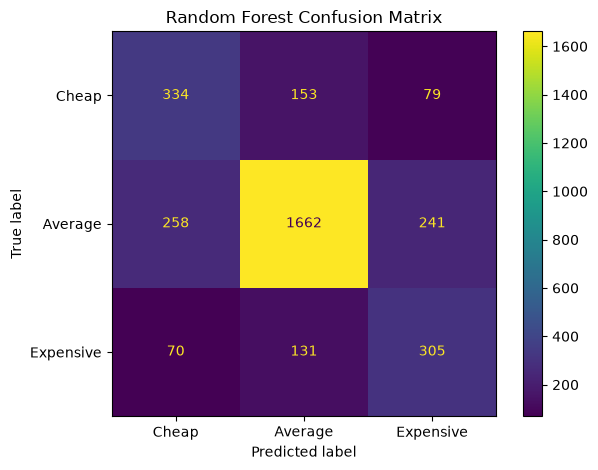

In [14]:
# Random Forest confusion matrix
class_order = ['Cheap', 'Average', 'Expensive']

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=class_order
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=class_order
).plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. XGBoost Classification

XGBoost (Extreme Gradient Boosting) builds decision trees sequentially.
Each new tree attempts to improve on errors made by previous trees.

XGBoost uses the **same training and testing split and the same leakage-safe
feature set** as Random Forest, making the model comparison fair.

In [15]:
# Encode the target labels for XGBoost
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for label, code_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} -> {code_value}")

Class mapping:
Average -> 0
Cheap -> 1
Expensive -> 2


In [16]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [17]:
# Train XGBoost
xgb_pipeline.fit(
    X_train,
    y_train_encoded
)

# Predict on unseen test data
y_pred_xgb_encoded = xgb_pipeline.predict(X_test)

# Convert predictions back to original labels
y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

print("XGBoost training and prediction completed.")

XGBoost training and prediction completed.


In [18]:
# Evaluate XGBoost
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_macro_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='macro'
)

xgb_weighted_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost Macro F1: {xgb_macro_f1:.4f}")
print(f"XGBoost Weighted F1: {xgb_weighted_f1:.4f}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7321
XGBoost Macro F1: 0.5696
XGBoost Weighted F1: 0.7038

XGBoost Classification Report:
              precision    recall  f1-score   support

     Average       0.76      0.93      0.84      2161
       Cheap       0.57      0.36      0.44       566
   Expensive       0.63      0.33      0.43       506

    accuracy                           0.73      3233
   macro avg       0.66      0.54      0.57      3233
weighted avg       0.71      0.73      0.70      3233



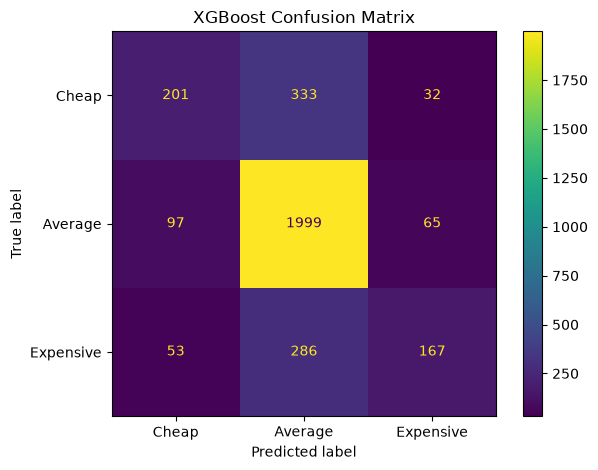

In [19]:
# XGBoost confusion matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=class_order
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=class_order
).plot()

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Model Comparison

The two models are compared using the same test observations and the same
leakage-safe feature set.

Accuracy measures overall correctness. Macro F1 gives equal importance to
Cheap, Average, and Expensive, while Weighted F1 accounts for the number of
observations in each class.

In [20]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Macro F1': [rf_macro_f1, xgb_macro_f1],
    'Weighted F1': [rf_weighted_f1, xgb_weighted_f1]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.711723,0.630890,0.720632
1,XGBoost,0.732137,0.569576,0.703821


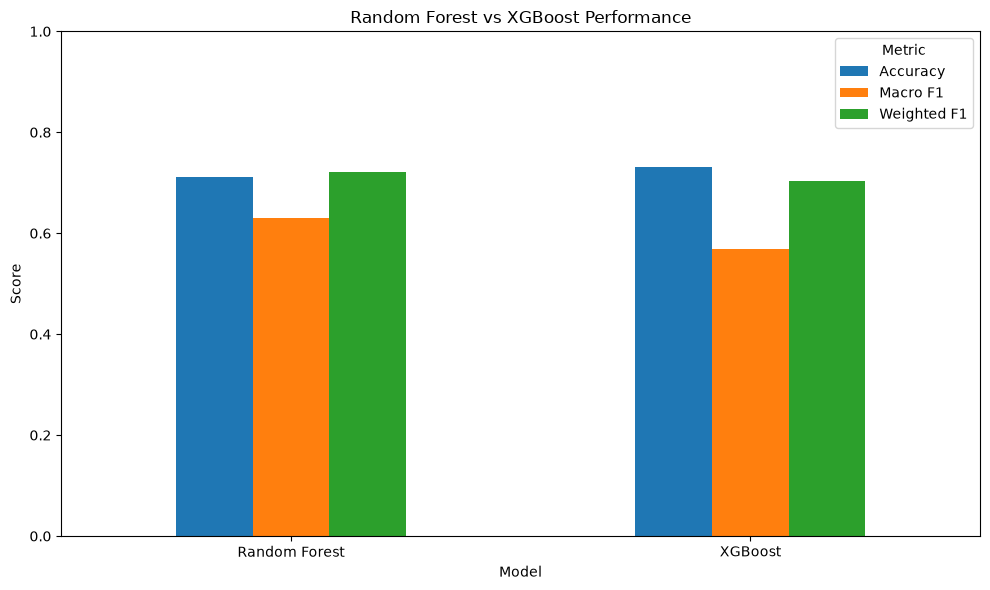

In [21]:
comparison_plot = comparison.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Random Forest vs XGBoost Performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance is examined to identify which predictors contributed most
to the final Random Forest and XGBoost models.

These importance scores indicate predictive contribution; they should not be
interpreted as proof that a feature causes food prices to change.

In [22]:
# Random Forest feature importance
rf_feature_names = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

rf_importance = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

rf_feature_importance = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importance
}).sort_values(
    by='Importance',
    ascending=False
)

rf_feature_importance.head(15)

,Feature,Importance
283,num__rainfall_mm,0.085995
286,num__diesel_price_kes,0.075217
279,num__market_id,0.070025
281,num__longitude,0.065724
280,num__latitude,0.065376
284,num__month,0.059410
285,num__year,0.052295
282,num__commodity_id,0.045981
276,cat__season_Dry Season,0.017033
277,cat__season_Long Rains,0.015651


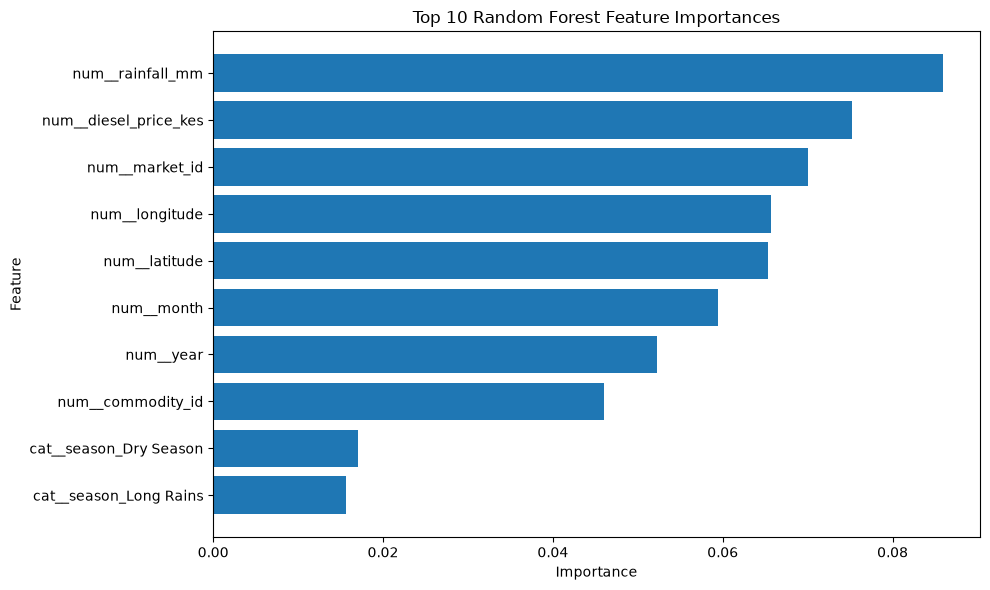

In [23]:
# Top 10 Random Forest features
top_rf = rf_feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_rf['Feature'],
    top_rf['Importance']
)

plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [24]:
# XGBoost feature importance
xgb_feature_names = xgb_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

xgb_importance = xgb_pipeline.named_steps[
    'classifier'
].feature_importances_

xgb_feature_importance = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': xgb_importance
}).sort_values(
    by='Importance',
    ascending=False
)

xgb_feature_importance.head(15)

,Feature,Importance
271,cat__priceflag_actual,0.060067
272,cat__priceflag_aggregate,0.053641
22,cat__county_Turkana,0.015732
19,cat__county_Samburu,0.015516
2,cat__region_Nairobi,0.013459
11,cat__county_Kitui,0.013056
119,cat__market_Kitui,0.011937
135,cat__market_Lodwar (Turkana),0.011525
18,cat__county_Nairobi,0.011470
4,cat__region_Rift Valley,0.010489


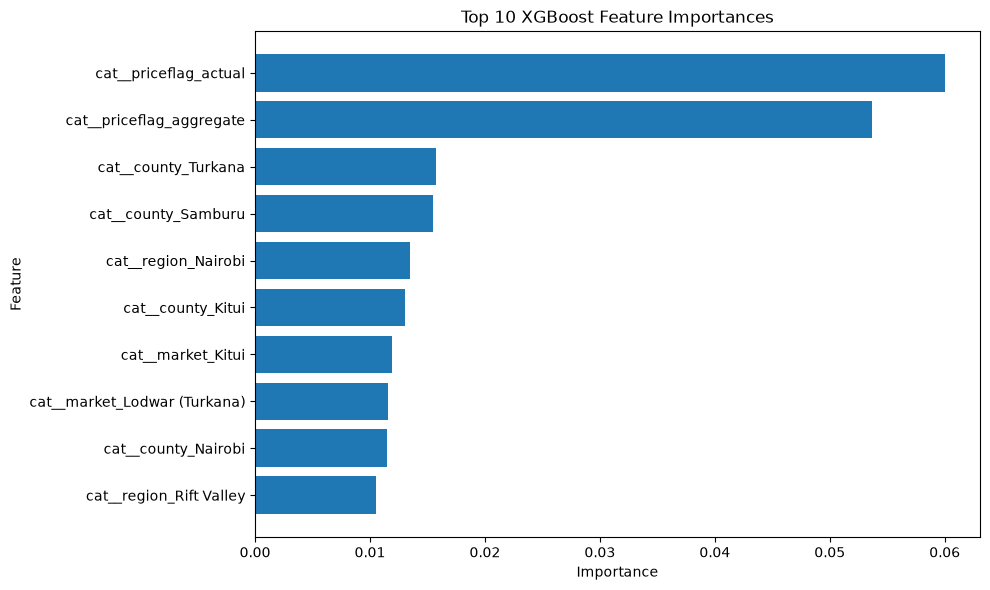

In [25]:
# Top 10 XGBoost features
top_xgb = xgb_feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_xgb['Feature'],
    top_xgb['Importance']
)

plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 9. Final Model Selection

The preferred model is selected using more than accuracy alone.

If one model has slightly higher accuracy but another model has stronger
Macro F1, Macro F1 is important here because the project needs performance
across all three price categories rather than mainly the majority class.

In [26]:
best_macro_f1_model = comparison.loc[
    comparison['Macro F1'].idxmax(),
    'Model'
]

best_accuracy_model = comparison.loc[
    comparison['Accuracy'].idxmax(),
    'Model'
]

print(f"Highest accuracy: {best_accuracy_model}")
print(f"Highest Macro F1: {best_macro_f1_model}")

if best_macro_f1_model == 'Random Forest':
    selected_model = 'Random Forest'
else:
    selected_model = best_macro_f1_model

print(f"\nSelected model based on Macro F1: {selected_model}")

Highest accuracy: XGBoost
Highest Macro F1: Random Forest

Selected model based on Macro F1: Random Forest


## 10. Limitations

- The target variable is imbalanced, with the Average category representing
  the majority of observations.
- Cheap and Expensive categories are harder to classify than Average.
- Market and commodity identifiers may limit generalization to completely
  unseen markets or commodities.
- The evaluation uses a random train-test split. Because food prices are
  observed repeatedly across markets and time, temporal or grouped validation
  would provide a stronger assessment of real-world generalization.
- Price-derived variables were excluded from the final feature set to reduce
  the risk of target leakage.

## Conclusion

Two ensemble classification models, Random Forest and XGBoost, were developed
to classify Kenyan food prices into Cheap, Average, and Expensive categories.

Both models were trained using the **same leakage-safe feature set and the same
80/20 stratified train-test split**.

The final comparison should be interpreted using accuracy together with Macro F1,
because the target classes are imbalanced. The model with the stronger Macro F1
provides the more balanced classification performance across the three price
categories.

The feature-importance analysis identifies the predictors that contributed most
to the models, while the limitations highlight the need for temporal or
market-based validation before deployment.